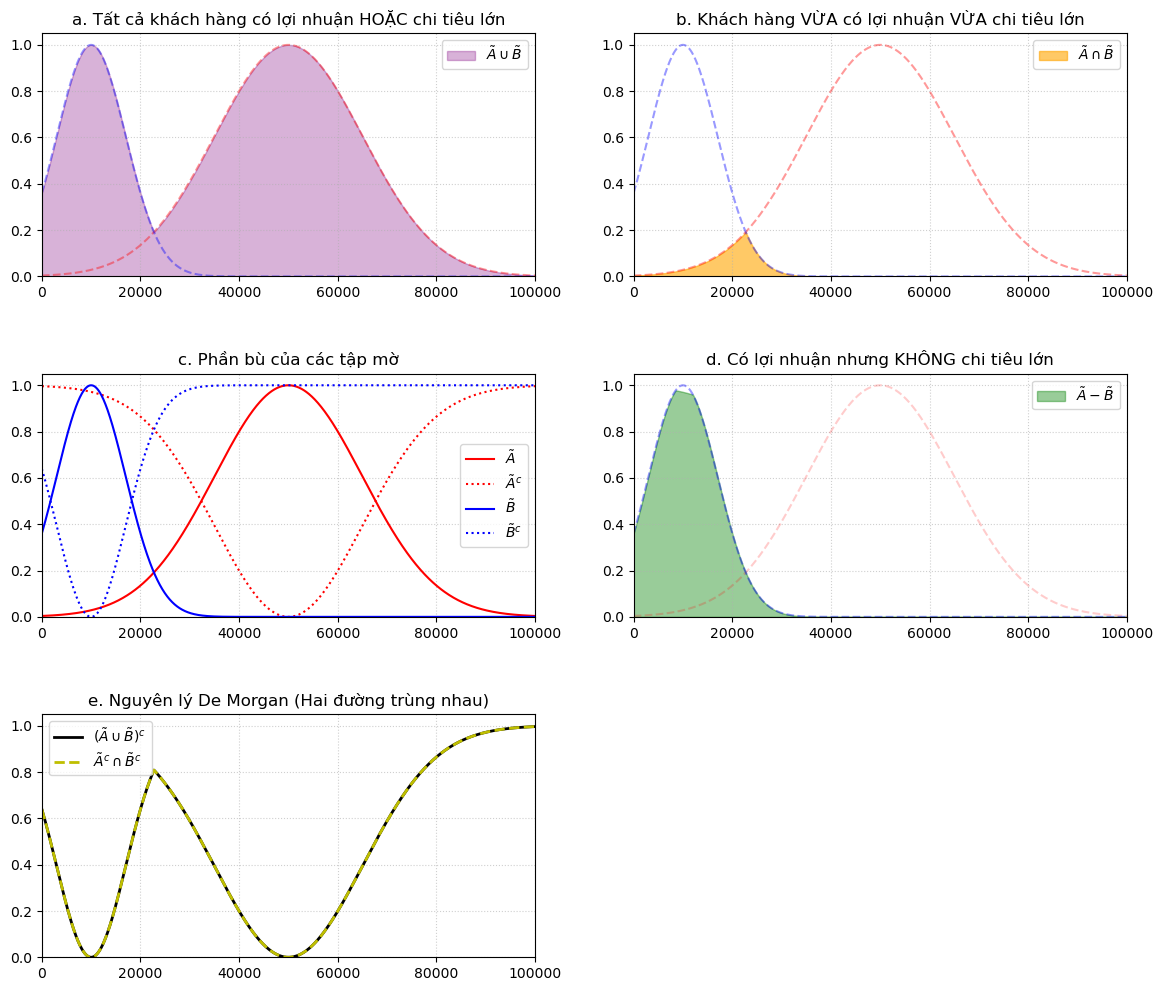

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Định nghĩa không gian nền x (Số tiền từ 0 đến 100,000)
x = np.linspace(0, 100000, 1000)

# 2. Định nghĩa hàm thuộc cho các tập mờ cơ sở
# Tập B: Khách hàng có lợi nhuận (đỉnh tại 10,000)
mu_B = np.exp(-0.5 * ((x - 10000) / 7000)**2)

# Tập A: Khách hàng chi tiêu lớn (đỉnh tại 50,000)
mu_A = np.exp(-0.5 * ((x - 50000) / 15000)**2)

# 3. Tính toán các phép toán tập mờ
mu_union = np.maximum(mu_A, mu_B)             # a. A U B (Hợp)
mu_inter = np.minimum(mu_A, mu_B)             # b. A ∩ B (Giao)
mu_not_A = 1 - mu_A                           # c. Bù A
mu_not_B = 1 - mu_B                           # c. Bù B
mu_diff  = np.minimum(mu_B, 1 - mu_A)          # d. B - A (Hiệu)
mu_de_morgan_lhs = 1 - mu_union               # e. vế trái De Morgan
mu_de_morgan_rhs = np.minimum(mu_not_A, mu_not_B) # e. vế phải De Morgan

# 4. Vẽ đồ thị
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.2)

# Câu a: Phép hợp
axes[0, 0].plot(x, mu_A, 'r--', alpha=0.4)
axes[0, 0].plot(x, mu_B, 'b--', alpha=0.4)
axes[0, 0].fill_between(x, mu_union, color='purple', alpha=0.3, label='$\~{A} \cup \~{B}$')
axes[0, 0].set_title("a. Tất cả khách hàng có lợi nhuận HOẶC chi tiêu lớn")
axes[0, 0].legend()

# Câu b: Phép giao
axes[0, 1].plot(x, mu_A, 'r--', alpha=0.4)
axes[0, 1].plot(x, mu_B, 'b--', alpha=0.4)
axes[0, 1].fill_between(x, mu_inter, color='orange', alpha=0.6, label='$\~{A} \cap \~{B}$')
axes[0, 1].set_title("b. Khách hàng VỪA có lợi nhuận VỪA chi tiêu lớn")
axes[0, 1].legend()

# Câu c: Phép bù
axes[1, 0].plot(x, mu_A, 'r', label='$\~{A}$')
axes[1, 0].plot(x, mu_not_A, 'r:', label='$\~{A}^c$')
axes[1, 0].plot(x, mu_B, 'b', label='$\~{B}$')
axes[1, 0].plot(x, mu_not_B, 'b:', label='$\~{B}^c$')
axes[1, 0].set_title("c. Phần bù của các tập mờ")
axes[1, 0].legend(loc='center right')

# Câu d: Phép hiệu
axes[1, 1].plot(x, mu_A, 'r--', alpha=0.2)
axes[1, 1].plot(x, mu_B, 'b--', alpha=0.4)
axes[1, 1].fill_between(x, mu_diff, color='green', alpha=0.4, label='$\~{A} - \~{B}$')
axes[1, 1].set_title("d. Có lợi nhuận nhưng KHÔNG chi tiêu lớn")
axes[1, 1].legend()

# Câu e: Nguyên lý De Morgan
axes[2, 0].plot(x, mu_de_morgan_lhs, 'k', lw=2, label='$( \~{A} \cup \~{B} )^c$')
axes[2, 0].plot(x, mu_de_morgan_rhs, 'y--', lw=2, label='$\~{A}^c \cap \~{B}^c$')
axes[2, 0].set_title("e. Nguyên lý De Morgan (Hai đường trùng nhau)")
axes[2, 0].legend()

# Xóa subplot dư thừa
axes[2, 1].axis('off')

# Định dạng chung cho các trục
for ax in axes.flat:
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, 100000)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.show()

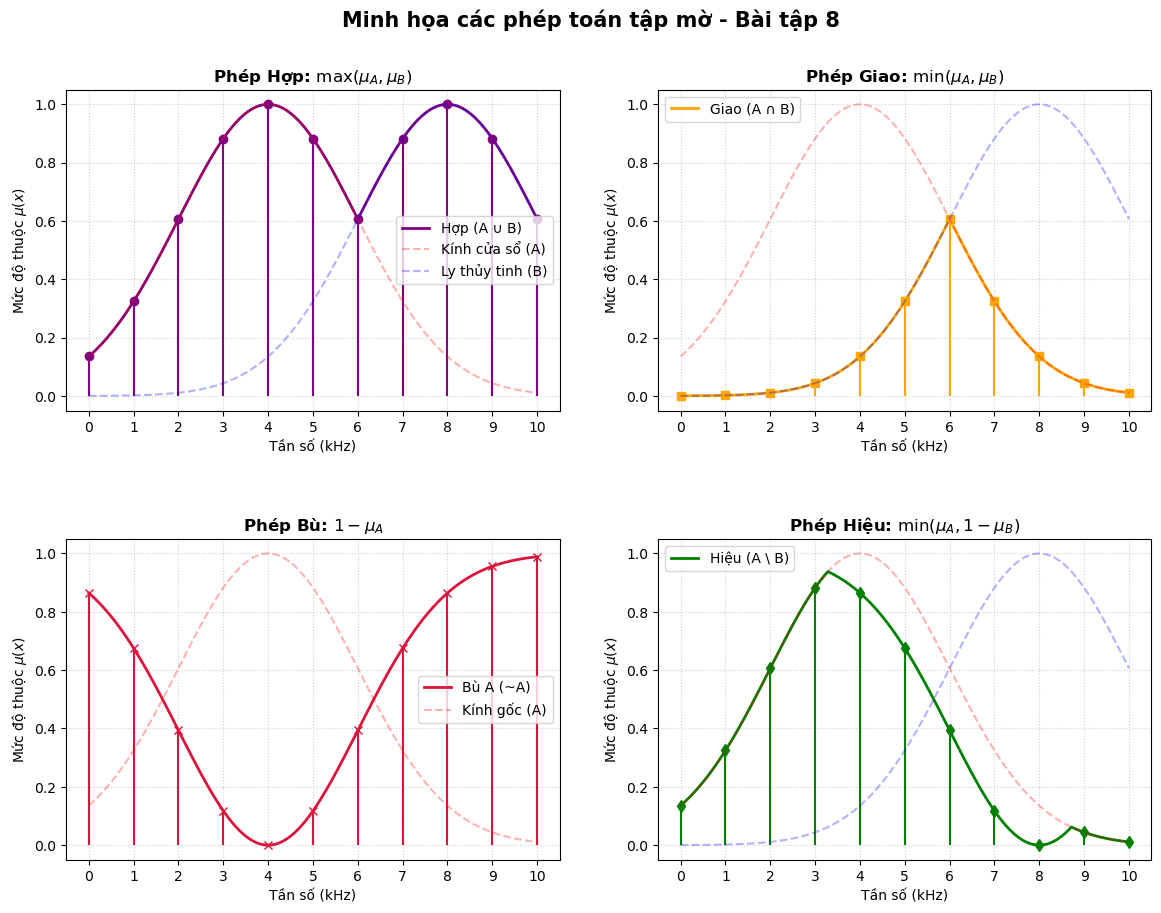

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Định nghĩa tập nền rời rạc X theo đề bài
x_discrete = np.arange(0, 11)

# Tạo mảng x mịn để vẽ đường đồ thị nền liên tục giúp trực quan hơn
x_smooth = np.linspace(0, 10, 500)

def gauss_mf(x, mu, sigma=2):
    return np.exp(-0.5 * ((x - mu) / sigma)**2)

# Tính toán giá trị hàm thuộc cho cả dạng mịn và dạng rời rạc
mu_A_smooth = gauss_mf(x_smooth, mu=4)
mu_B_smooth = gauss_mf(x_smooth, mu=8)

mu_A_disc = gauss_mf(x_discrete, mu=4)
mu_B_disc = gauss_mf(x_discrete, mu=8)

# Thiết lập hệ thống khung đồ thị gồm 4 ô (subplots)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.2)

# --- Ô 1: Phép Hợp (Union) ---
axes[0, 0].plot(x_smooth, np.maximum(mu_A_smooth, mu_B_smooth), 'purple', lw=2, label='Hợp (A ∪ B)')
axes[0, 0].stem(x_discrete, np.maximum(mu_A_disc, mu_B_disc), linefmt='purple', markerfmt='o', basefmt=' ')
axes[0, 0].plot(x_smooth, mu_A_smooth, 'r--', alpha=0.3, label='Kính cửa sổ (A)')
axes[0, 0].plot(x_smooth, mu_B_smooth, 'b--', alpha=0.3, label='Ly thủy tinh (B)')
axes[0, 0].set_title('Phép Hợp: $\max(\mu_A, \mu_B)$', fontsize=12, fontweight='bold')
axes[0, 0].legend()

# --- Ô 2: Phép Giao (Intersection) ---
axes[0, 1].plot(x_smooth, np.minimum(mu_A_smooth, mu_B_smooth), 'orange', lw=2, label='Giao (A ∩ B)')
axes[0, 1].stem(x_discrete, np.minimum(mu_A_disc, mu_B_disc), linefmt='orange', markerfmt='s', basefmt=' ')
axes[0, 1].plot(x_smooth, mu_A_smooth, 'r--', alpha=0.3)
axes[0, 1].plot(x_smooth, mu_B_smooth, 'b--', alpha=0.3)
axes[0, 1].set_title('Phép Giao: $\min(\mu_A, \mu_B)$', fontsize=12, fontweight='bold')
axes[0, 1].legend()

# --- Ô 3: Phép Bù (Complement) ---
axes[1, 0].plot(x_smooth, 1 - mu_A_smooth, 'crimson', lw=2, label='Bù A (~A)')
axes[1, 0].stem(x_discrete, 1 - mu_A_disc, linefmt='crimson', markerfmt='x', basefmt=' ')
axes[1, 0].plot(x_smooth, mu_A_smooth, 'r--', alpha=0.3, label='Kính gốc (A)')
axes[1, 0].set_title('Phép Bù: $1 - \mu_A$', fontsize=12, fontweight='bold')
axes[1, 0].legend()

# --- Ô 4: Phép Hiệu (Difference: A \ B) ---
mu_diff_smooth = np.minimum(mu_A_smooth, 1 - mu_B_smooth)
mu_diff_disc = np.minimum(mu_A_disc, 1 - mu_B_disc)
axes[1, 1].plot(x_smooth, mu_diff_smooth, 'green', lw=2, label='Hiệu (A \\ B)')
axes[1, 1].stem(x_discrete, mu_diff_disc, linefmt='green', markerfmt='d', basefmt=' ')
axes[1, 1].plot(x_smooth, mu_A_smooth, 'r--', alpha=0.3)
axes[1, 1].plot(x_smooth, mu_B_smooth, 'b--', alpha=0.3)
axes[1, 1].set_title('Phép Hiệu: $\min(\mu_A, 1 - \mu_B)$', fontsize=12, fontweight='bold')
axes[1, 1].legend()

# Cấu hình định dạng hiển thị chung cho các đồ thị con
for ax in axes.flat:
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks(x_discrete)
    ax.set_xlabel('Tần số (kHz)')
    ax.set_ylabel('Mức độ thuộc $\mu(x)$')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Minh họa các phép toán tập mờ - Bài tập 8', fontsize=15, fontweight='bold', y=0.96)
plt.show()